In [ ]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn scipy -q
!pip install sentence-transformers -q
!pip install accelerate -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from scipy import stats
import torch
import time
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries installed")
print(f"✓ GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

✓ All libraries installed
✓ GPU available: True
✓ GPU: Tesla T4


2

In [ ]:
from datasets import load_dataset

print("="*80)
print("LOADING HumAID DATASET")
print("="*80)

fire_data      = load_dataset("QCRI/HumAID-event-type", 'fire',      verification_mode="no_checks")
earthquake_data = load_dataset("QCRI/HumAID-event-type", 'earthquake', verification_mode="no_checks")
flood_data     = load_dataset("QCRI/HumAID-event-type", 'flood',     verification_mode="no_checks")
hurricane_data = load_dataset("QCRI/HumAID-event-type", 'hurricane', verification_mode="no_checks")

fire_df      = pd.DataFrame(fire_data['train'].to_dict())
earthquake_df = pd.DataFrame(earthquake_data['train'].to_dict())
flood_df     = pd.DataFrame(flood_data['train'].to_dict())
hurricane_df  = pd.DataFrame(hurricane_data['train'].to_dict())

print(f"Columns: {fire_df.columns.tolist()}")
print(f"Fire: {len(fire_df)} | Earthquake: {len(earthquake_df)} | Flood: {len(flood_df)} | Hurricane: {len(hurricane_df)}")

actionable_categories = [
    'caution_and_advice',
    'displaced_people_and_evacuations',
    'infrastructure_and_utility_damage',
    'requests_or_urgent_needs',
    'rescue_volunteering_or_donation_effort'
]

def create_binary_label(class_label):
    return 1 if class_label in actionable_categories else 0

for df, name in zip([fire_df, earthquake_df, flood_df, hurricane_df],
                     ['fire','earthquake','flood','hurricane']):
    df['binary_label'] = df['class_label'].apply(create_binary_label)
    df['event_type_name'] = name

# Keep only needed columns
for df in [fire_df, earthquake_df, flood_df, hurricane_df]:
    cols = [c for c in df.columns if c not in ['tweet_text','binary_label','event_type_name']]
    df.drop(columns=cols, inplace=True)

print(f"\nFire   - Actionable: {fire_df['binary_label'].sum()}, Noise: {(1-fire_df['binary_label']).sum()}")
print(f"Earthquake - Actionable: {earthquake_df['binary_label'].sum()}, Noise: {(1-earthquake_df['binary_label']).sum()}")
print(f"Flood  - Actionable: {flood_df['binary_label'].sum()}, Noise: {(1-flood_df['binary_label']).sum()}")
print(f"Hurricane - Actionable: {hurricane_df['binary_label'].sum()}, Noise: {(1-hurricane_df['binary_label']).sum()}")
print("✓ Dataset loaded")
print("="*80)

LOADING HumAID DATASET


README.md:   0%|          | 0.00/4.40k [00:00<?, ?B/s]

train.json:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

dev.json:   0%|          | 0.00/322k [00:00<?, ?B/s]

test.json:   0%|          | 0.00/626k [00:00<?, ?B/s]

...

test.json:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/31674 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/4613 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8966 [00:00<?, ? examples/s]

Columns: ['tweet_id', 'tweet_text', 'class_label']
Fire: 7792 | Earthquake: 6250 | Flood: 7815 | Hurricane: 31674

Fire   - Actionable: 3191, Noise: 4601
Earthquake - Actionable: 2601, Noise: 3649
Flood  - Actionable: 4932, Noise: 2883
Hurricane - Actionable: 18289, Noise: 13385
✓ Dataset loaded


3

In [ ]:
print("="*80)
print("CREATING TRAINING AND EVALUATION SETS")
print("="*80)

np.random.seed(42)
fire_shuffled   = fire_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Fixed evaluation set (1000 tweets, never seen by any model)
test_eval      = fire_shuffled.head(1000).copy()
fire_remaining = fire_shuffled.iloc[1000:].reset_index(drop=True)

# M3: All remaining wildfire tweets
train_m3 = fire_remaining.copy()

# M2: 5000 mixed balanced (1250 per event type)
samples_per_event = 5000 // 4
train_m2_balanced = pd.concat([
    earthquake_df.sample(n=samples_per_event, random_state=42),
    flood_df.sample(n=samples_per_event, random_state=42),
    hurricane_df.sample(n=samples_per_event, random_state=42),
    fire_remaining.sample(n=samples_per_event, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# M6: Only 64 wildfire samples (few-shot)
train_m6 = fire_remaining.sample(n=64, random_state=42).copy()

print(f"Evaluation set : {len(test_eval)} tweets | Actionable: {test_eval['binary_label'].sum()} | Noise: {(1-test_eval['binary_label']).sum()}")
print(f"M2 training    : {len(train_m2_balanced)} mixed disaster tweets")
print(f"M3 training    : {len(train_m3)} wildfire tweets")
print(f"M6 training    : {len(train_m6)} wildfire tweets (few-shot)")
print("="*80)

CREATING TRAINING AND EVALUATION SETS
Evaluation set : 1000 tweets | Actionable: 392 | Noise: 608
M2 training    : 5000 mixed disaster tweets
M3 training    : 6792 wildfire tweets
M6 training    : 64 wildfire tweets (few-shot)


4

In [ ]:
from transformers import pipeline

print("="*80)
print("M1: ZERO-SHOT BART-MNLI")
print("="*80)

classifier_bart = pipeline("zero-shot-classification",
                            model="facebook/bart-large-mnli")

y_true_m1, y_pred_m1 = [], []
start = time.time()

for i, row in test_eval.iterrows():
    try:
        result = classifier_bart(
            row['tweet_text'],
            ['actionable emergency alert', 'general noise or sympathy']
        )
        pred = 1 if result['labels'][0] == 'actionable emergency alert' else 0
    except:
        pred = 0
    y_true_m1.append(row['binary_label'])
    y_pred_m1.append(pred)

m1_time = time.time() - start
f1_m1   = f1_score(y_true_m1, y_pred_m1, zero_division=0)
prec_m1 = precision_score(y_true_m1, y_pred_m1, zero_division=0)
rec_m1  = recall_score(y_true_m1, y_pred_m1, zero_division=0)

print(classification_report(y_true_m1, y_pred_m1,
      target_names=['Noise','Actionable'], zero_division=0))
print(f"F1: {f1_m1:.4f} | Precision: {prec_m1:.4f} | Recall: {rec_m1:.4f} | Time: {m1_time:.1f}s")
print("="*80)

M1: ZERO-SHOT BART-MNLI


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


              precision    recall  f1-score   support

       Noise       0.64      0.67      0.65       608
  Actionable       0.44      0.40      0.42       392

    accuracy                           0.57      1000
   macro avg       0.54      0.54      0.54      1000
weighted avg       0.56      0.57      0.56      1000

F1: 0.4225 | Precision: 0.4438 | Recall: 0.4031 | Time: 44.0s


5

In [ ]:
from sentence_transformers import CrossEncoder

print("="*80)
print("M4: BERT-NLI (Parameter-Efficient)")
print("="*80)

model_bert_nli = CrossEncoder('cross-encoder/nli-MiniLM2-L6-H768')

y_true_m4, y_pred_m4 = [], []
start = time.time()

for _, row in test_eval.iterrows():
    scores = model_bert_nli.predict(
        [[row['tweet_text'], "This is an actionable emergency alert"]]
    )
    entailment_score = scores[0][2]
    pred = 1 if entailment_score > 0.5 else 0
    y_true_m4.append(row['binary_label'])
    y_pred_m4.append(pred)

m4_time = time.time() - start
f1_m4   = f1_score(y_true_m4, y_pred_m4, zero_division=0)
prec_m4 = precision_score(y_true_m4, y_pred_m4, zero_division=0)
rec_m4  = recall_score(y_true_m4, y_pred_m4, zero_division=0)

print(classification_report(y_true_m4, y_pred_m4,
      target_names=['Noise','Actionable'], zero_division=0))
print(f"F1: {f1_m4:.4f} | Precision: {prec_m4:.4f} | Recall: {rec_m4:.4f} | Time: {m4_time:.1f}s")
print("="*80)

M4: BERT-NLI (Parameter-Efficient)


config.json:   0%|          | 0.00/875 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

              precision    recall  f1-score   support

       Noise       0.71      0.02      0.04       608
  Actionable       0.39      0.99      0.56       392

    accuracy                           0.40      1000
   macro avg       0.55      0.50      0.30      1000
weighted avg       0.58      0.40      0.24      1000

F1: 0.5629 | Precision: 0.3937 | Recall: 0.9872 | Time: 6.3s


6

In [ ]:
# Cell 6: M5 - DeBERTa-v3 Zero-Shot (FAST REPLACEMENT)
print("="*80)
print("M5: DeBERTa-v3-small ZERO-SHOT NLI (LLM-based)")
print("="*80)

from transformers import pipeline

classifier_deberta = pipeline(
    "zero-shot-classification",
    model="cross-encoder/nli-deberta-v3-small",
    device=0 if torch.cuda.is_available() else -1
)

y_true_m5, y_pred_m5 = [], []
start = time.time()

for i, (_, row) in enumerate(test_eval.iterrows()):
    try:
        result = classifier_deberta(
            row['tweet_text'],
            ['actionable emergency alert', 'general noise or sympathy']
        )
        pred = 1 if result['labels'][0] == 'actionable emergency alert' else 0
    except:
        pred = 0
    y_true_m5.append(row['binary_label'])
    y_pred_m5.append(pred)

    if (i+1) % 100 == 0:
        print(f"Progress: {i+1}/1000 | Time: {time.time()-start:.1f}s")

m5_time = time.time() - start
f1_m5   = f1_score(y_true_m5, y_pred_m5, zero_division=0)
prec_m5 = precision_score(y_true_m5, y_pred_m5, zero_division=0)
rec_m5  = recall_score(y_true_m5, y_pred_m5, zero_division=0)

print(classification_report(y_true_m5, y_pred_m5,
      target_names=['Noise','Actionable'], zero_division=0))
print(f"F1: {f1_m5:.4f} | Precision: {prec_m5:.4f} | Recall: {rec_m5:.4f} | Time: {m5_time:.1f}s")
print("="*80)

M5: DeBERTa-v3-small ZERO-SHOT NLI (LLM-based)


config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Progress: 100/1000 | Time: 3.7s
Progress: 200/1000 | Time: 6.4s
Progress: 300/1000 | Time: 9.1s
Progress: 400/1000 | Time: 11.8s
Progress: 500/1000 | Time: 14.4s
Progress: 600/1000 | Time: 17.0s
Progress: 700/1000 | Time: 19.8s
Progress: 800/1000 | Time: 22.5s
Progress: 900/1000 | Time: 25.2s
Progress: 1000/1000 | Time: 27.9s
              precision    recall  f1-score   support

       Noise       0.67      0.39      0.50       608
  Actionable       0.43      0.70      0.53       392

    accuracy                           0.51      1000
   macro avg       0.55      0.55      0.51      1000
weighted avg       0.57      0.51      0.51      1000

F1: 0.5300 | Precision: 0.4268 | Recall: 0.6990 | Time: 27.9s


7

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression

print("="*80)
print("M6: SETFIT-STYLE FEW-SHOT (64 samples)")
print("="*80)

# Load sentence transformer backbone
backbone = SentenceTransformer("sentence-transformers/paraphrase-mpnet-base-v2")

train_texts  = train_m6['tweet_text'].tolist()
train_labels = train_m6['binary_label'].tolist()

# Encode training samples
print("Encoding 64 training samples...")
start = time.time()
train_embeddings = backbone.encode(train_texts, show_progress_bar=False)

# Train logistic regression on embeddings
clf_setfit = LogisticRegression(max_iter=1000, random_state=42)
clf_setfit.fit(train_embeddings, train_labels)
m6_train_time = time.time() - start
print(f"✓ Training complete in {m6_train_time:.1f}s")

# Evaluate
print("Evaluating on 1,000 wildfire test tweets...")
start = time.time()
test_embeddings = backbone.encode(
    test_eval['tweet_text'].tolist(),
    show_progress_bar=True,
    batch_size=64
)
y_pred_m6 = clf_setfit.predict(test_embeddings).tolist()
m6_infer_time = time.time() - start

y_true_m6 = test_eval['binary_label'].tolist()
f1_m6   = f1_score(y_true_m6, y_pred_m6, zero_division=0)
prec_m6 = precision_score(y_true_m6, y_pred_m6, zero_division=0)
rec_m6  = recall_score(y_true_m6, y_pred_m6, zero_division=0)

print(classification_report(y_true_m6, y_pred_m6,
      target_names=['Noise','Actionable'], zero_division=0))
print(f"F1: {f1_m6:.4f} | Precision: {prec_m6:.4f} | Recall: {rec_m6:.4f}")
print(f"Train time: {m6_train_time:.1f}s | Inference time: {m6_infer_time:.1f}s")
print("="*80)

M6: SETFIT-STYLE FEW-SHOT (64 samples)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.73k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 64 training samples...
✓ Training complete in 0.3s
Evaluating on 1,000 wildfire test tweets...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

              precision    recall  f1-score   support

       Noise       0.86      0.83      0.85       608
  Actionable       0.75      0.80      0.77       392

    accuracy                           0.82      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.82      0.82      1000

F1: 0.7728 | Precision: 0.7488 | Recall: 0.7985
Train time: 0.3s | Inference time: 4.0s


8

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

print("="*80)
print("M2: ROBERTA FINE-TUNED ON MIXED DISASTERS")
print("="*80)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

def tokenize_fn(examples):
    return tokenizer(examples['tweet_text'],
                     padding='max_length', truncation=True, max_length=128)

def make_dataset(df):
    ds = Dataset.from_pandas(df[['tweet_text','binary_label']].reset_index(drop=True))
    ds = ds.rename_column('binary_label','label')
    ds = ds.map(tokenize_fn, batched=True)
    ds = ds.remove_columns(['tweet_text'])
    return ds

def evaluate_model(model, tokenizer, test_df, device):
    model.eval()
    y_true, y_pred = [], []
    for _, row in test_df.iterrows():
        enc = tokenizer(row['tweet_text'], max_length=128, truncation=True,
                       return_tensors='pt', padding='max_length')
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        pred = torch.argmax(out.logits, dim=1).item()
        y_true.append(row['binary_label'])
        y_pred.append(pred)
    return y_true, y_pred

# Prepare dataset
ds_m2 = make_dataset(train_m2_balanced)

# Load model
model_m2 = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

args_m2 = TrainingArguments(
    output_dir='./m2_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,
    seed=42,
    save_strategy="no",
    report_to="none"
)

trainer_m2 = Trainer(model=model_m2, args=args_m2, train_dataset=ds_m2)

print("Training M2 on 5,000 mixed disaster samples...")
start = time.time()
trainer_m2.train()
m2_train_time = time.time() - start
print(f"✓ M2 training complete in {m2_train_time:.1f}s")

model_m2.to(device)
start = time.time()
y_true_m2, y_pred_m2 = evaluate_model(model_m2, tokenizer, test_eval, device)
m2_infer_time = time.time() - start

f1_m2   = f1_score(y_true_m2, y_pred_m2, zero_division=0)
prec_m2 = precision_score(y_true_m2, y_pred_m2, zero_division=0)
rec_m2  = recall_score(y_true_m2, y_pred_m2, zero_division=0)

print(classification_report(y_true_m2, y_pred_m2,
      target_names=['Noise','Actionable'], zero_division=0))
print(f"F1: {f1_m2:.4f} | Precision: {prec_m2:.4f} | Recall: {rec_m2:.4f}")
print(f"Train: {m2_train_time:.1f}s | Inference: {m2_infer_time:.1f}s")
print("="*80)

M2: ROBERTA FINE-TUNED ON MIXED DISASTERS


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training M2 on 5,000 mixed disaster samples...


Step,Training Loss
100,0.592261
200,0.428897
300,0.418219
400,0.327408
500,0.326309
600,0.286960
700,0.201709
800,0.182675
900,0.188272


✓ M2 training complete in 106.9s
              precision    recall  f1-score   support

       Noise       0.94      0.89      0.91       608
  Actionable       0.84      0.91      0.87       392

    accuracy                           0.90      1000
   macro avg       0.89      0.90      0.89      1000
weighted avg       0.90      0.90      0.90      1000

F1: 0.8733 | Precision: 0.8432 | Recall: 0.9056
Train: 106.9s | Inference: 13.4s


9

In [ ]:
print("="*80)
print("M3: ROBERTA FINE-TUNED ON WILDFIRE ONLY (PROPOSED)")
print("="*80)

ds_m3    = make_dataset(train_m3)
model_m3 = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

args_m3 = TrainingArguments(
    output_dir='./m3_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,
    seed=42,
    save_strategy="no",
    report_to="none"
)

trainer_m3 = Trainer(model=model_m3, args=args_m3, train_dataset=ds_m3)

print("Training M3 on wildfire-specific samples...")
start = time.time()
trainer_m3.train()
m3_train_time = time.time() - start
print(f"✓ M3 training complete in {m3_train_time:.1f}s")

model_m3.to(device)
start = time.time()
y_true_m3, y_pred_m3 = evaluate_model(model_m3, tokenizer, test_eval, device)
m3_infer_time = time.time() - start

f1_m3   = f1_score(y_true_m3, y_pred_m3, zero_division=0)
prec_m3 = precision_score(y_true_m3, y_pred_m3, zero_division=0)
rec_m3  = recall_score(y_true_m3, y_pred_m3, zero_division=0)

print(classification_report(y_true_m3, y_pred_m3,
      target_names=['Noise','Actionable'], zero_division=0))
print(f"F1: {f1_m3:.4f} | Precision: {prec_m3:.4f} | Recall: {rec_m3:.4f}")
print(f"Train: {m3_train_time:.1f}s | Inference: {m3_infer_time:.1f}s")
print("="*80)

M3: ROBERTA FINE-TUNED ON WILDFIRE ONLY (PROPOSED)


Map:   0%|          | 0/6792 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training M3 on wildfire-specific samples...


Step,Training Loss
100,0.546632
200,0.413526
300,0.327701
400,0.310481
500,0.233356
600,0.225735
700,0.241355
800,0.243625
900,0.193289
1000,0.139466


✓ M3 training complete in 144.7s
              precision    recall  f1-score   support

       Noise       0.95      0.90      0.92       608
  Actionable       0.85      0.92      0.89       392

    accuracy                           0.91      1000
   macro avg       0.90      0.91      0.90      1000
weighted avg       0.91      0.91      0.91      1000

F1: 0.8862 | Precision: 0.8518 | Recall: 0.9235
Train: 144.7s | Inference: 13.1s


10

In [ ]:
print("="*80)
print("FINAL RESULTS: ALL 6 MODELS")
print("="*80)

models_list = ['M1: BART (Zero-Shot)', 'M4: BERT-NLI', 'M5: Phi-1.5 (LLM)',
               'M6: SetFit (64 samples)', 'M2: RoBERTa-Mixed', 'M3: RoBERTa-Wildfire']

f1_scores    = [f1_m1, f1_m4, f1_m5, f1_m6, f1_m2, f1_m3]
prec_scores  = [prec_m1, prec_m4, prec_m5, prec_m6, prec_m2, prec_m3]
rec_scores   = [rec_m1, rec_m4, rec_m5, rec_m6, rec_m2, rec_m3]
params_list  = ['406M', '22M', '1.3B', '66M', '125M', '125M']
train_data   = ['0', '0', '0', '64', '5,000', '6,792']
train_times  = [f'0s', f'0s', f'0s', f'{m6_train_time:.0f}s',
                f'{m2_train_time:.0f}s', f'{m3_train_time:.0f}s']

df_results = pd.DataFrame({
    'Model': models_list,
    'F1': [round(s, 3) for s in f1_scores],
    'Precision': [round(s, 3) for s in prec_scores],
    'Recall': [round(s, 3) for s in rec_scores],
    'Params': params_list,
    'Train Data': train_data,
    'Train Time': train_times
})

print(df_results.to_string(index=False))

# Error analysis
all_preds = [y_pred_m1, y_pred_m4, y_pred_m5, y_pred_m6, y_pred_m2, y_pred_m3]
all_trues = [y_true_m1, y_true_m4, y_true_m5, y_true_m6, y_true_m2, y_true_m3]

fn_list = [sum(1 for t,p in zip(yt,yp) if t==1 and p==0) for yt,yp in zip(all_trues, all_preds)]
fp_list = [sum(1 for t,p in zip(yt,yp) if t==0 and p==1) for yt,yp in zip(all_trues, all_preds)]
total_list = [fn+fp for fn,fp in zip(fn_list, fp_list)]

df_errors = pd.DataFrame({
    'Model': models_list,
    'FN': fn_list,
    'FP': fp_list,
    'Total': total_list,
    'Params': params_list
})

print(f"\nError Distribution:\n{df_errors.to_string(index=False)}")
print("="*80)

FINAL RESULTS: ALL 6 MODELS
                  Model    F1  Precision  Recall Params Train Data Train Time
   M1: BART (Zero-Shot) 0.422      0.444   0.403   406M          0         0s
           M4: BERT-NLI 0.563      0.394   0.987    22M          0         0s
      M5: Phi-1.5 (LLM) 0.530      0.427   0.699   1.3B          0         0s
M6: SetFit (64 samples) 0.773      0.749   0.798    66M         64         0s
      M2: RoBERTa-Mixed 0.873      0.843   0.906   125M      5,000       107s
   M3: RoBERTa-Wildfire 0.886      0.852   0.923   125M      6,792       145s

Error Distribution:
                  Model  FN  FP  Total Params
   M1: BART (Zero-Shot) 234 198    432   406M
           M4: BERT-NLI   5 596    601    22M
      M5: Phi-1.5 (LLM) 118 368    486   1.3B
M6: SetFit (64 samples)  79 105    184    66M
      M2: RoBERTa-Mixed  37  66    103   125M
   M3: RoBERTa-Wildfire  30  63     93   125M


11

In [ ]:
from scipy import stats

print("="*80)
print("STATISTICAL SIGNIFICANCE: M2 vs M3")
print("="*80)

y_true = np.array(test_eval['binary_label'].values)
y_pred_m2_np = np.array(y_pred_m2)
y_pred_m3_np = np.array(y_pred_m3)

def bootstrap_ci(y_true, y_pred, n_iterations=1000):
    scores = []
    for i in range(n_iterations):
        indices = resample(range(len(y_true)), n_samples=len(y_true), random_state=i)
        scores.append(f1_score(y_true[indices], y_pred[indices], zero_division=0))
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

m2_mean, m2_lower, m2_upper = bootstrap_ci(y_true, y_pred_m2_np)
m3_mean, m3_lower, m3_upper = bootstrap_ci(y_true, y_pred_m3_np)

print(f"M2 Bootstrap F1: {m2_mean:.4f} [95% CI: {m2_lower:.4f}, {m2_upper:.4f}]")
print(f"M3 Bootstrap F1: {m3_mean:.4f} [95% CI: {m3_lower:.4f}, {m3_upper:.4f}]")

def mcnemar_test(y_true, y_pred1, y_pred2):
    b = np.sum((y_pred1 == y_true) & (y_pred2 != y_true))
    c = np.sum((y_pred1 != y_true) & (y_pred2 == y_true))
    n = b + c
    if n == 0:
        return None, None
    stat = (abs(b - c) - 1) ** 2 / n
    p_value = 1 - stats.chi2.cdf(stat, df=1)
    return stat, p_value

mcnemar_stat, mcnemar_p = mcnemar_test(y_true, y_pred_m2_np, y_pred_m3_np)
ci_overlap = not (m2_upper < m3_lower or m3_upper < m2_lower)

print(f"\nMcNemar's Test: stat={mcnemar_stat:.4f}, p={mcnemar_p:.4f}")
print(f"Significant (p<0.05): {'YES' if mcnemar_p < 0.05 else 'NO'}")
print(f"Bootstrap CIs overlap: {ci_overlap}")
print("="*80)

STATISTICAL SIGNIFICANCE: M2 vs M3
M2 Bootstrap F1: 0.8729 [95% CI: 0.8484, 0.8953]
M3 Bootstrap F1: 0.8854 [95% CI: 0.8627, 0.9066]

McNemar's Test: stat=1.4464, p=0.2291
Significant (p<0.05): NO
Bootstrap CIs overlap: True


12

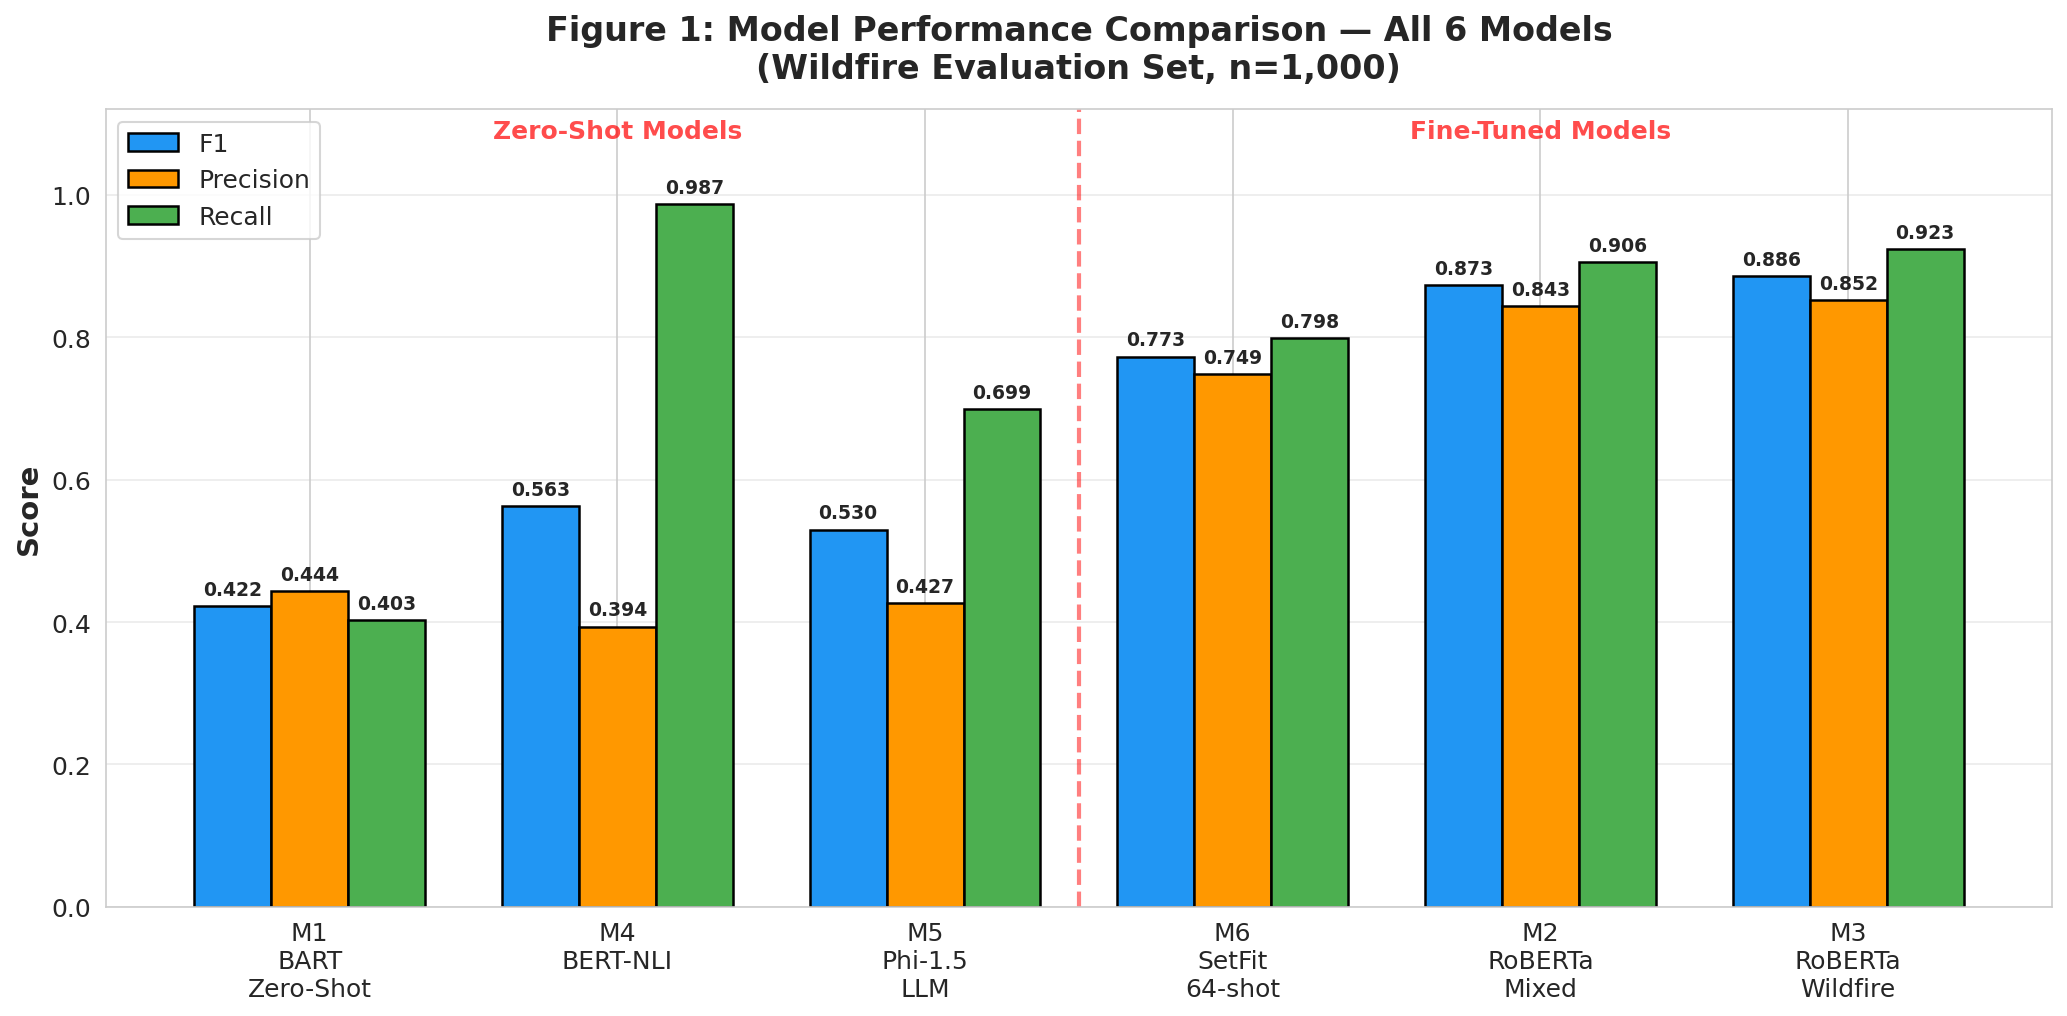

✓ Figure 1 saved


In [ ]:
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 150
})

# ── FIGURE 1: Main Metrics Comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

short_names = ['M1\nBART\nZero-Shot', 'M4\nBERT-NLI', 'M5\nPhi-1.5\nLLM',
               'M6\nSetFit\n64-shot', 'M2\nRoBERTa\nMixed', 'M3\nRoBERTa\nWildfire']

x = np.arange(len(short_names))
width = 0.25

bars1 = ax.bar(x - width, f1_scores,   width, label='F1',        color='#2196F3', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x,         prec_scores, width, label='Precision',  color='#FF9800', edgecolor='black', linewidth=1.2)
bars3 = ax.bar(x + width, rec_scores,  width, label='Recall',     color='#4CAF50', edgecolor='black', linewidth=1.2)

# Value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Figure 1: Model Performance Comparison — All 6 Models\n(Wildfire Evaluation Set, n=1,000)',
             fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.set_ylim(0, 1.12)
ax.legend(loc='upper left')
ax.axvline(x=2.5, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax.text(1.0, 1.08, 'Zero-Shot Models', ha='center', fontsize=12,
        color='red', alpha=0.7, fontweight='bold')
ax.text(4.0, 1.08, 'Fine-Tuned Models', ha='center', fontsize=12,
        color='red', alpha=0.7, fontweight='bold')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figure1_main_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved")

13

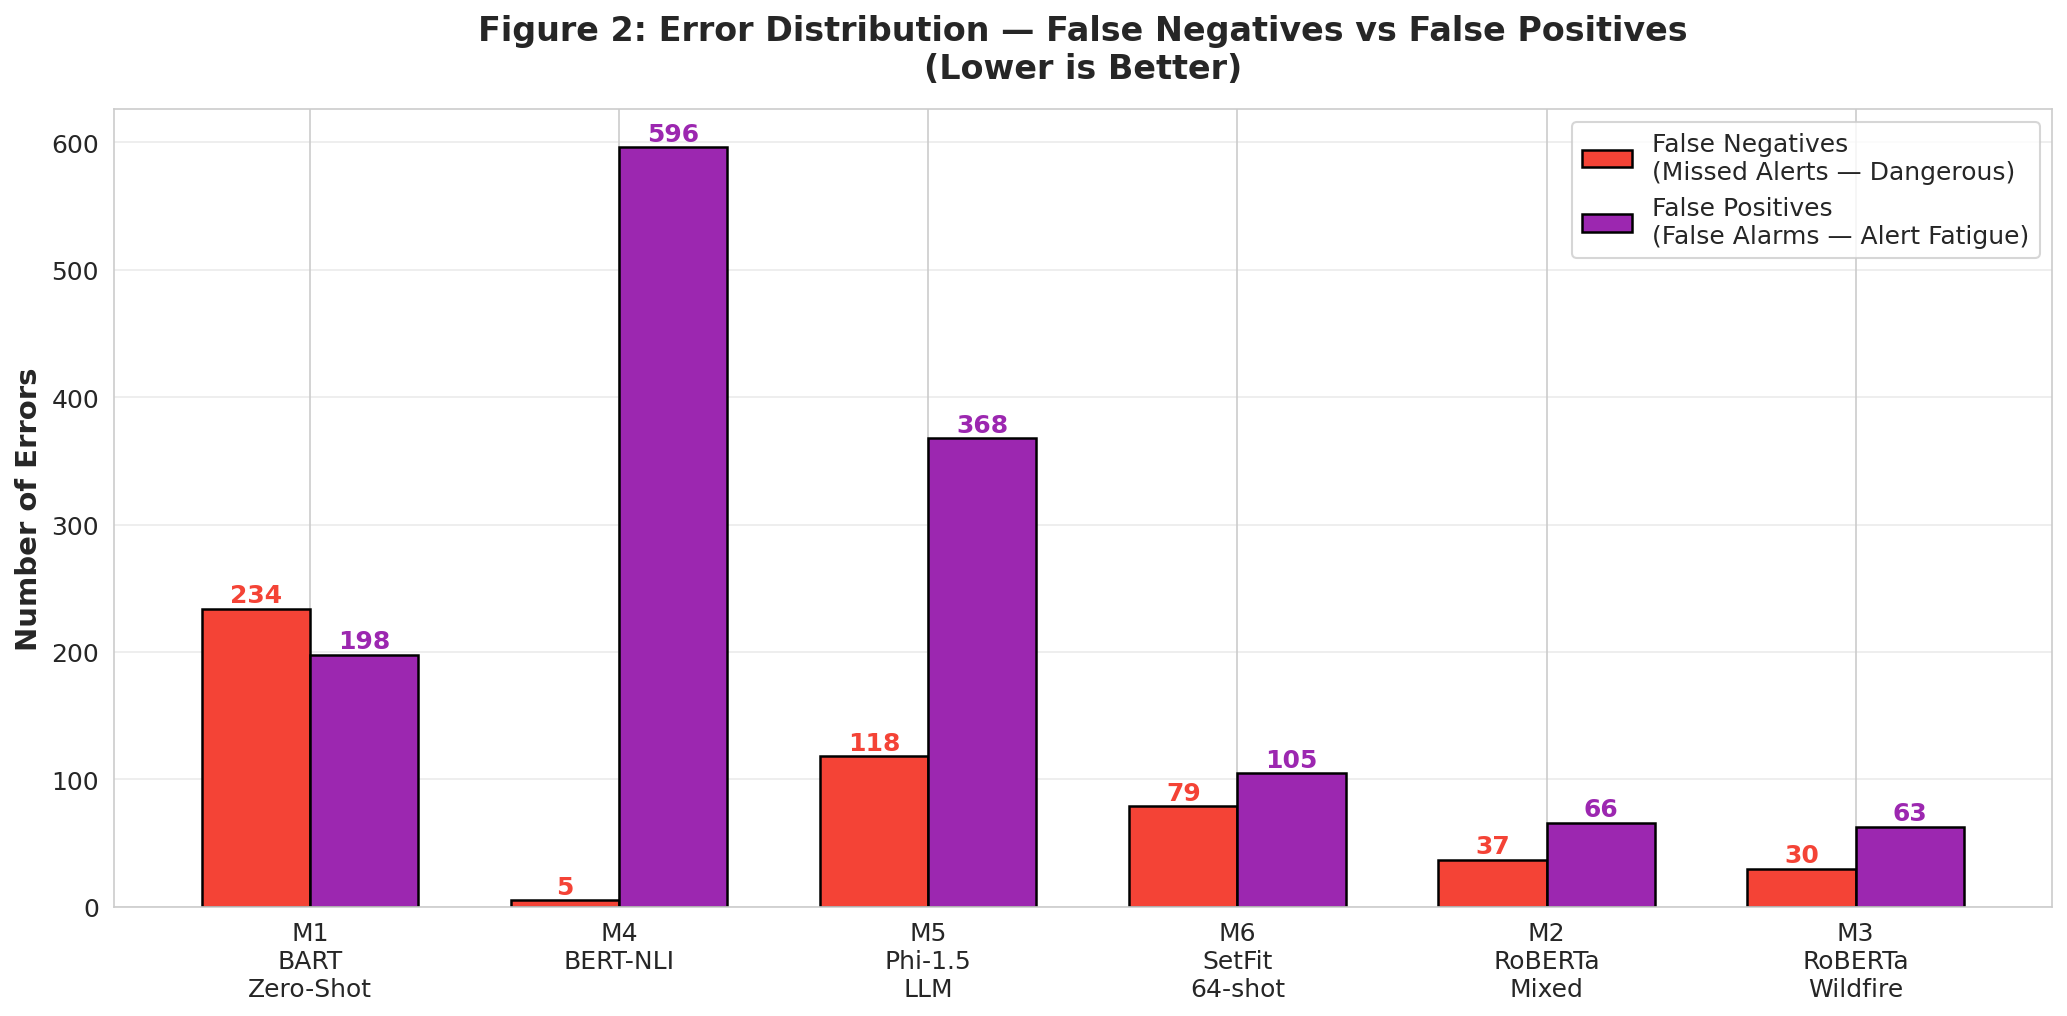

✓ Figure 2 saved


In [ ]:
# ── FIGURE 2: Error Distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(short_names))
width = 0.35

bars_fn = ax.bar(x - width/2, fn_list, width, label='False Negatives\n(Missed Alerts — Dangerous)',
                  color='#F44336', edgecolor='black', linewidth=1.2)
bars_fp = ax.bar(x + width/2, fp_list, width, label='False Positives\n(False Alarms — Alert Fatigue)',
                  color='#9C27B0', edgecolor='black', linewidth=1.2)

for bar in bars_fn:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold', color='#F44336')
for bar in bars_fp:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold', color='#9C27B0')

ax.set_ylabel('Number of Errors', fontweight='bold')
ax.set_title('Figure 2: Error Distribution — False Negatives vs False Positives\n(Lower is Better)',
             fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figure2_error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved")

14

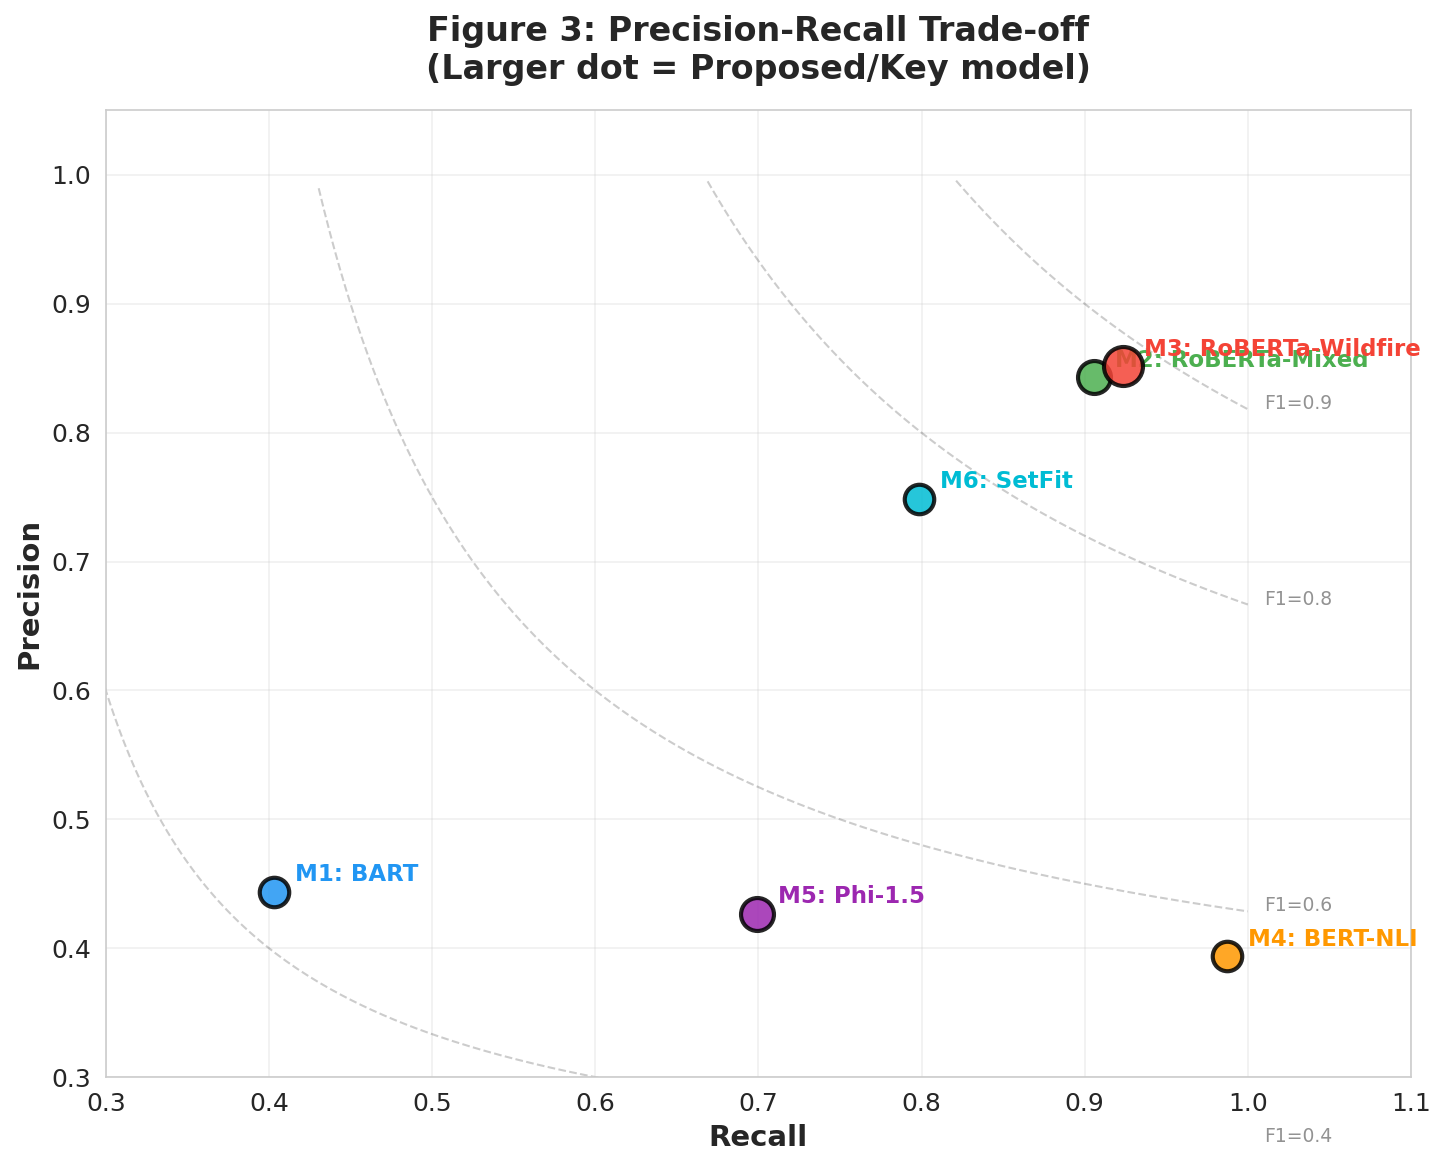

✓ Figure 3 saved


In [ ]:
# ── FIGURE 3: Precision-Recall Trade-off ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2196F3', '#FF9800', '#9C27B0', '#00BCD4', '#4CAF50', '#F44336']
sizes  = [200, 200, 250, 200, 250, 350]
labels_short = ['M1: BART', 'M4: BERT-NLI', 'M5: Phi-1.5',
                'M6: SetFit', 'M2: RoBERTa-Mixed', 'M3: RoBERTa-Wildfire']

for i, (model, prec, rec, color, size, label) in enumerate(
        zip(models_list, prec_scores, rec_scores, colors, sizes, labels_short)):
    ax.scatter(rec, prec, s=size, alpha=0.85, color=color,
               edgecolor='black', linewidth=2, zorder=5)
    ax.annotate(label, (rec, prec),
                textcoords="offset points", xytext=(10, 5),
                fontsize=11, fontweight='bold', color=color)

# F1 iso-lines
for f1_val in [0.4, 0.6, 0.8, 0.9]:
    x_vals = np.linspace(0.01, 1.0, 300)
    y_vals = (f1_val * x_vals) / (2 * x_vals - f1_val)
    valid = (y_vals > 0) & (y_vals <= 1)
    ax.plot(x_vals[valid], y_vals[valid], 'k--', alpha=0.2, linewidth=1)
    ax.text(x_vals[valid][-1] + 0.01, y_vals[valid][-1],
            f'F1={f1_val}', fontsize=9, alpha=0.5)

ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Figure 3: Precision-Recall Trade-off\n(Larger dot = Proposed/Key model)',
             fontweight='bold', pad=15)
ax.set_xlim(0.3, 1.1)
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")

15

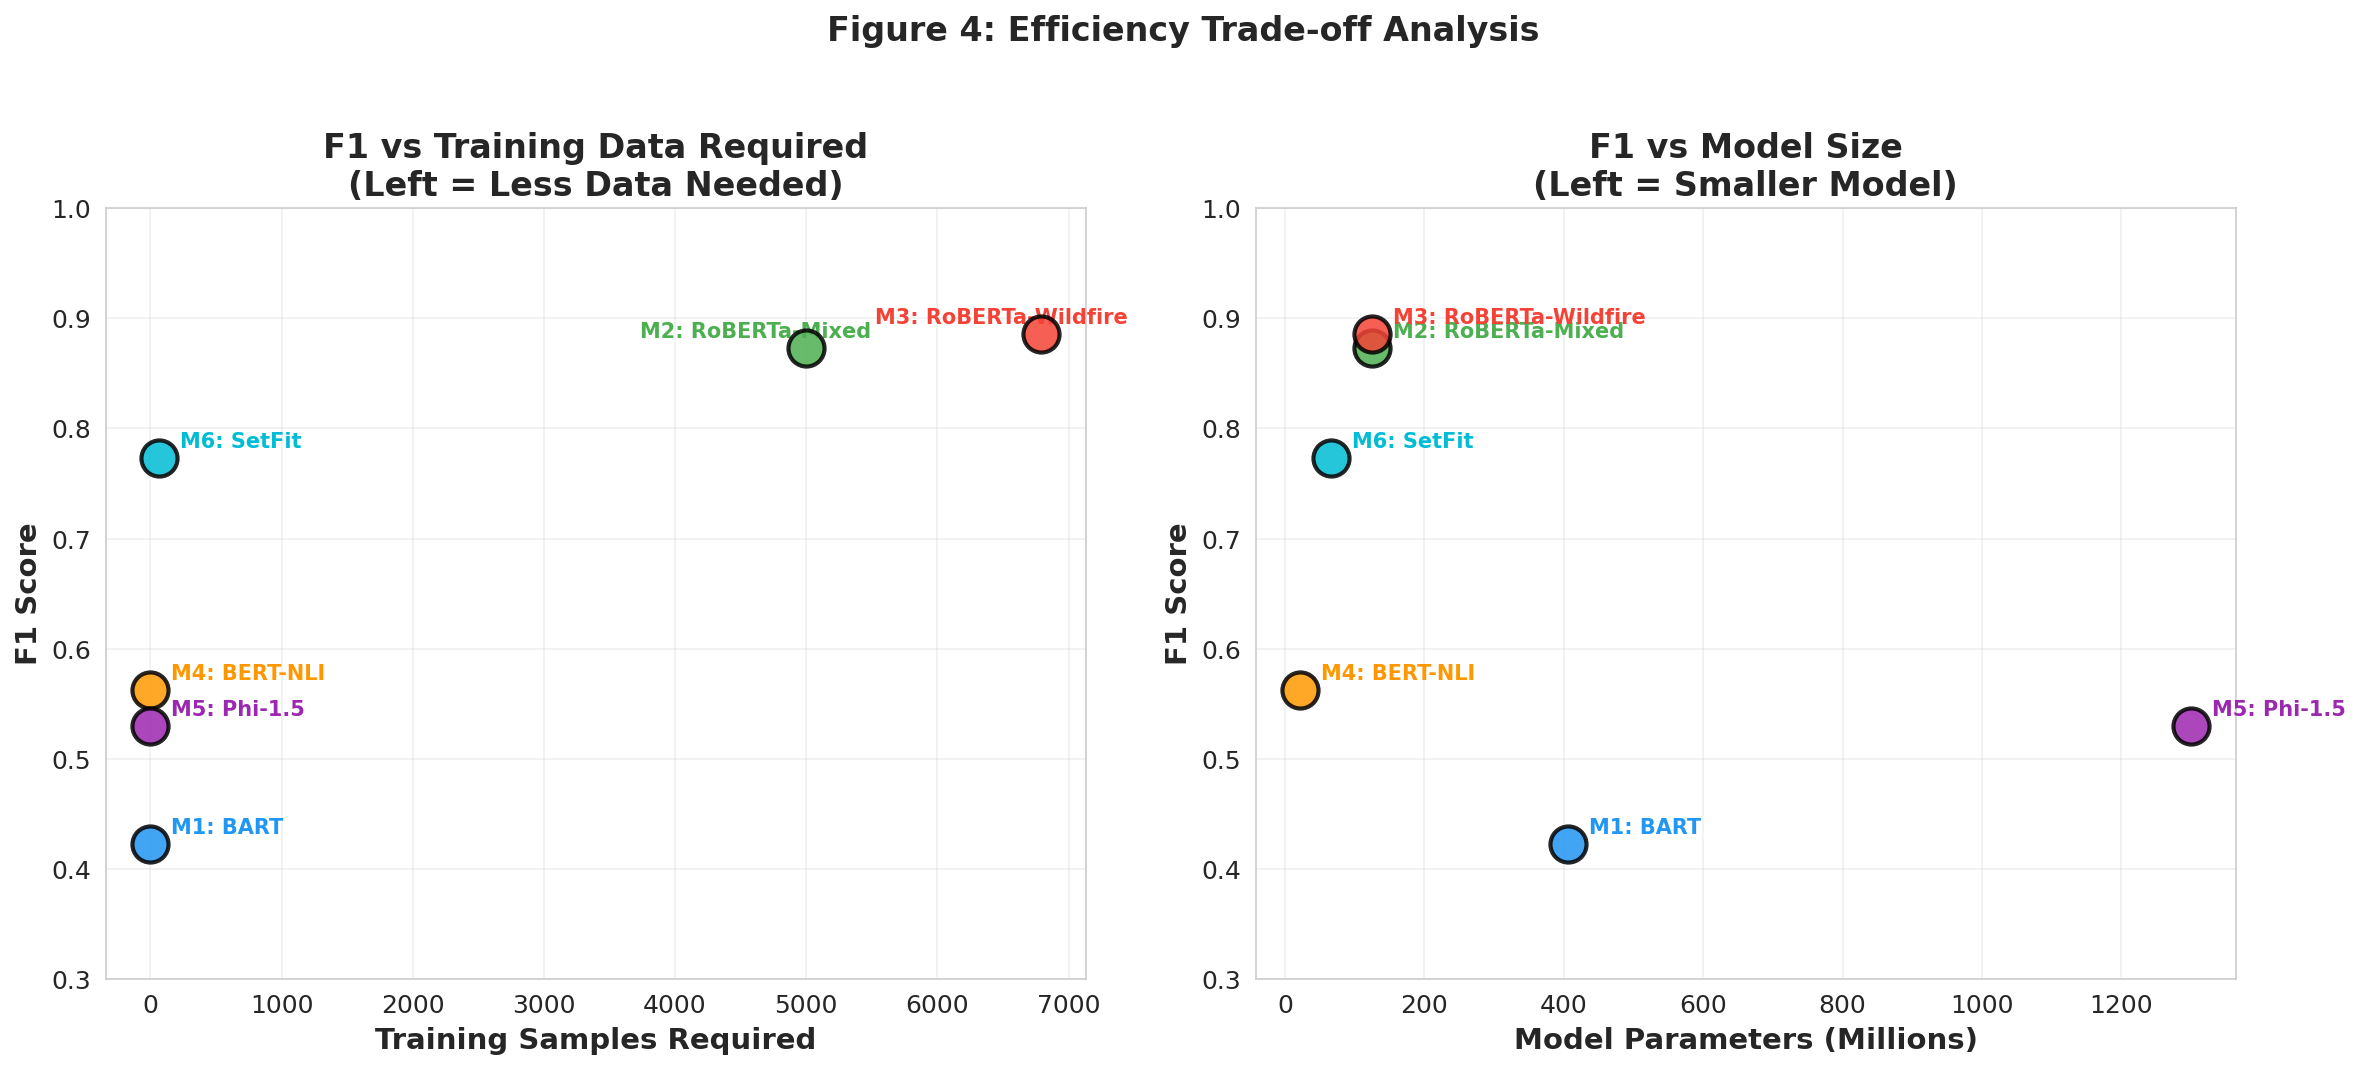

✓ Figure 4 saved


In [ ]:
# ── FIGURE 4: Efficiency Trade-off ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: F1 vs Training Data Required
ax1 = axes[0]
train_data_nums = [0, 0, 0, 64, 5000, 6792]

for i, (model, td, f1, color, label) in enumerate(
        zip(models_list, train_data_nums, f1_scores, colors, labels_short)):
    ax1.scatter(td, f1, s=300, color=color, edgecolor='black',
                linewidth=2, zorder=5, alpha=0.85)
    offset = (10, 5) if td < 3000 else (-80, 5)
    ax1.annotate(label, (td, f1),
                 textcoords="offset points", xytext=offset,
                 fontsize=10, fontweight='bold', color=color)

ax1.set_xlabel('Training Samples Required', fontweight='bold')
ax1.set_ylabel('F1 Score', fontweight='bold')
ax1.set_title('F1 vs Training Data Required\n(Left = Less Data Needed)', fontweight='bold')
ax1.set_ylim(0.3, 1.0)
ax1.grid(True, alpha=0.3)

# Right: F1 vs Model Size
ax2 = axes[1]
param_nums = [406, 22, 1300, 66, 125, 125]

for i, (model, params, f1, color, label) in enumerate(
        zip(models_list, param_nums, f1_scores, colors, labels_short)):
    ax2.scatter(params, f1, s=300, color=color, edgecolor='black',
                linewidth=2, zorder=5, alpha=0.85)
    ax2.annotate(label, (params, f1),
                 textcoords="offset points", xytext=(10, 5),
                 fontsize=10, fontweight='bold', color=color)

ax2.set_xlabel('Model Parameters (Millions)', fontweight='bold')
ax2.set_ylabel('F1 Score', fontweight='bold')
ax2.set_title('F1 vs Model Size\n(Left = Smaller Model)', fontweight='bold')
ax2.set_ylim(0.3, 1.0)
ax2.grid(True, alpha=0.3)

fig.suptitle('Figure 4: Efficiency Trade-off Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure4_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved")

16

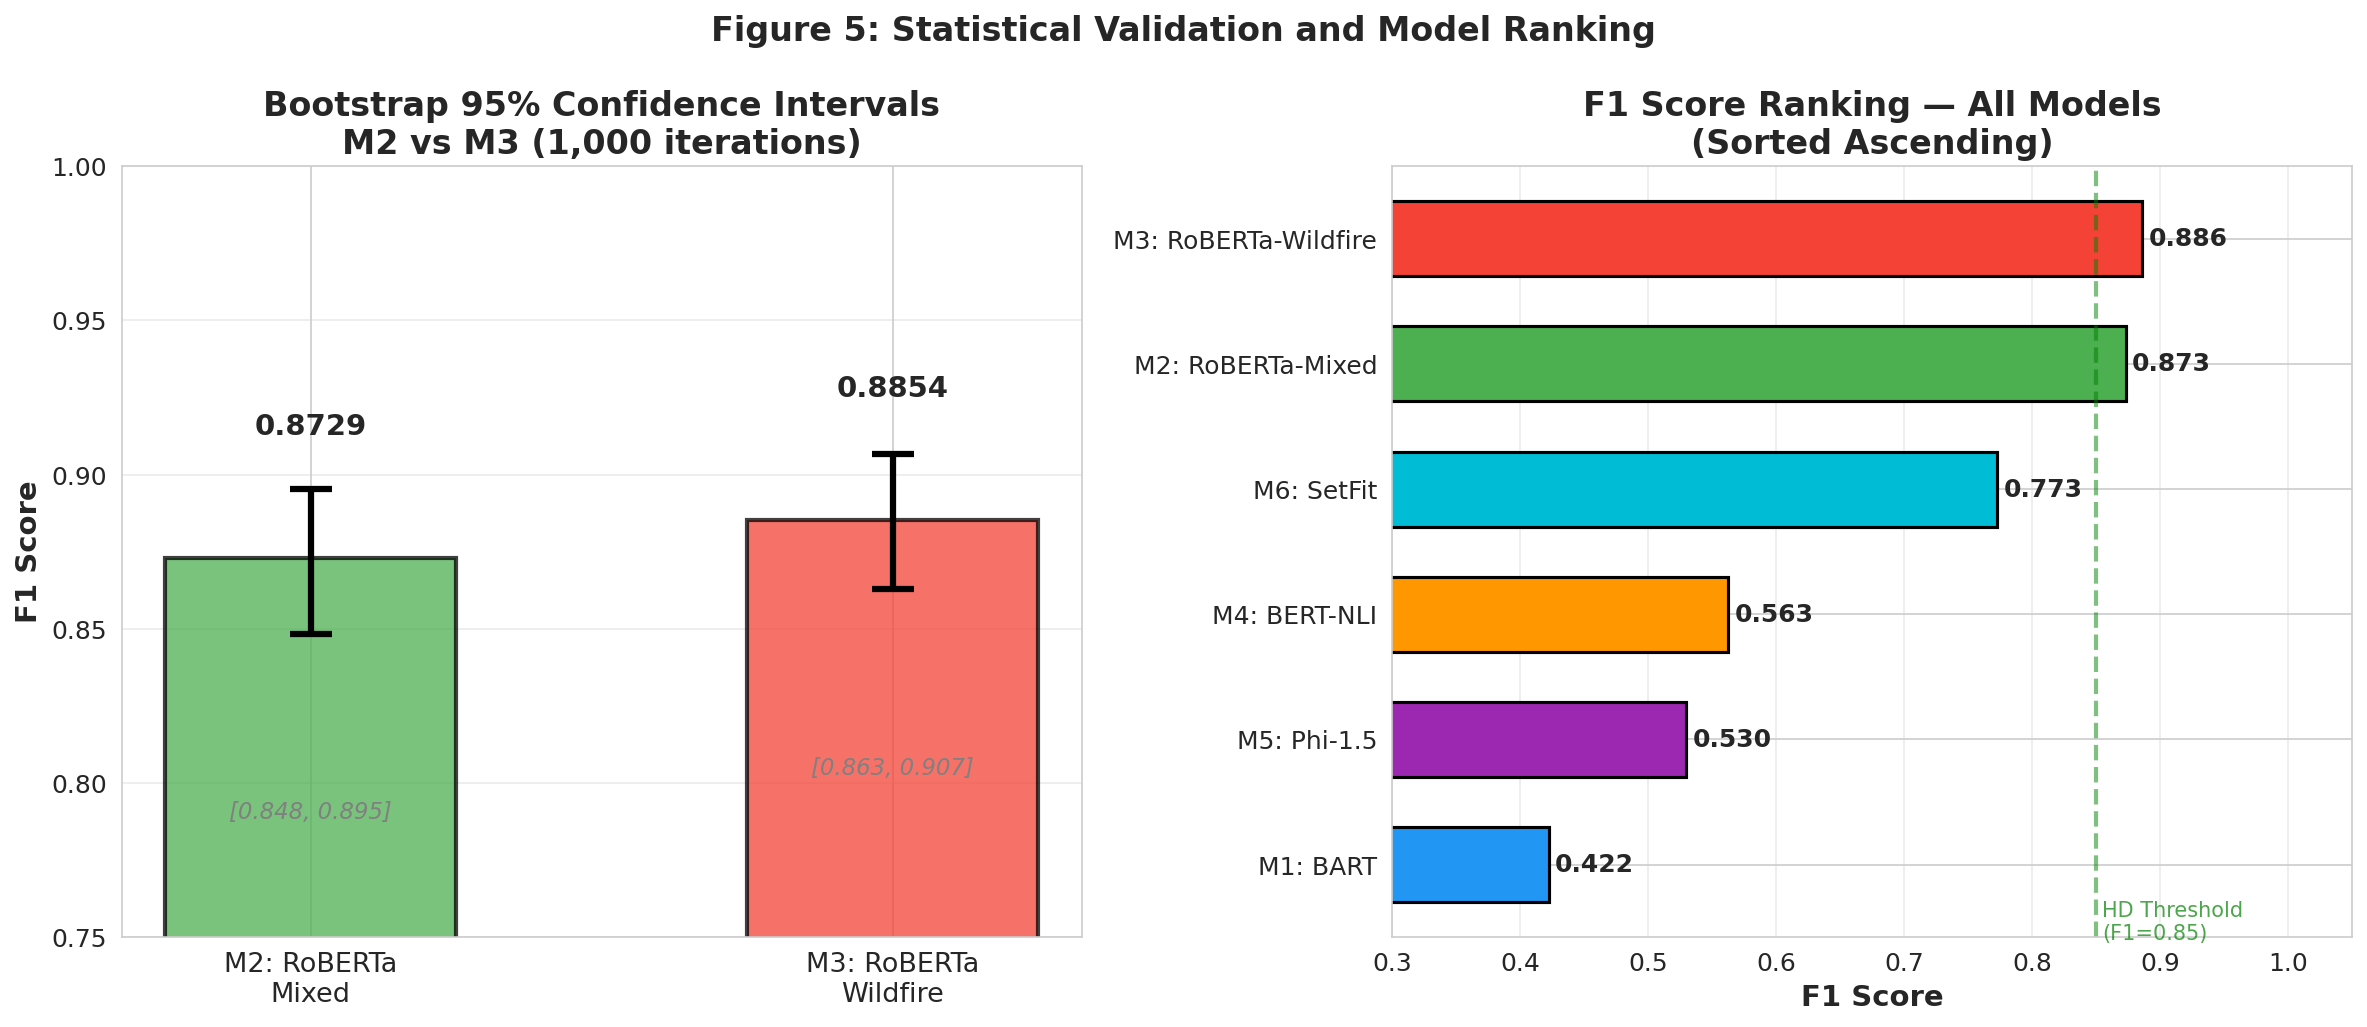

✓ Figure 5 saved


In [ ]:
# ── FIGURE 5: Bootstrap CIs + Statistical Summary ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Bootstrap CIs for M2 vs M3
ax1 = axes[0]
models_ci = ['M2: RoBERTa\nMixed', 'M3: RoBERTa\nWildfire']
f1_means  = [m2_mean, m3_mean]
ci_lower  = [m2_lower, m3_lower]
ci_upper  = [m2_upper, m3_upper]
bar_colors = ['#4CAF50', '#F44336']

bars = ax1.bar([0, 1], f1_means, color=bar_colors, edgecolor='black',
               linewidth=2, alpha=0.75, width=0.5)
ax1.errorbar([0, 1], f1_means,
             yerr=[[f1_means[i]-ci_lower[i] for i in range(2)],
                   [ci_upper[i]-f1_means[i] for i in range(2)]],
             fmt='none', ecolor='black', capsize=10, capthick=3, linewidth=3)

for i, (mean, lower, upper) in enumerate(zip(f1_means, ci_lower, ci_upper)):
    ax1.text(i, mean + 0.04, f'{mean:.4f}', ha='center', fontsize=14, fontweight='bold')
    ax1.text(i, lower - 0.06, f'[{lower:.3f}, {upper:.3f}]', ha='center',
             fontsize=11, style='italic', color='gray')

ax1.set_ylabel('F1 Score', fontweight='bold')
ax1.set_title('Bootstrap 95% Confidence Intervals\nM2 vs M3 (1,000 iterations)', fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(models_ci, fontsize=13)
ax1.set_ylim(0.75, 1.0)
ax1.grid(axis='y', alpha=0.4)

# Right: Full F1 comparison bar chart (clean, conference-ready)
ax2 = axes[1]
sorted_idx = np.argsort(f1_scores)
sorted_models = [labels_short[i] for i in sorted_idx]
sorted_f1 = [f1_scores[i] for i in sorted_idx]
sorted_colors = [colors[i] for i in sorted_idx]

bars = ax2.barh(range(len(sorted_models)), sorted_f1,
                color=sorted_colors, edgecolor='black', linewidth=1.5, height=0.6)

for i, (bar, val) in enumerate(zip(bars, sorted_f1)):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=12, fontweight='bold')

ax2.set_yticks(range(len(sorted_models)))
ax2.set_yticklabels(sorted_models, fontsize=12)
ax2.set_xlabel('F1 Score', fontweight='bold')
ax2.set_title('F1 Score Ranking — All Models\n(Sorted Ascending)', fontweight='bold')
ax2.set_xlim(0.3, 1.05)
ax2.axvline(x=0.85, color='green', linestyle='--', alpha=0.5, linewidth=2)
ax2.text(0.855, -0.6, 'HD Threshold\n(F1=0.85)', fontsize=10, color='green', alpha=0.7)
ax2.grid(axis='x', alpha=0.4)

fig.suptitle('Figure 5: Statistical Validation and Model Ranking', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure5_stats_ranking.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 5 saved")

17

In [ ]:
print("\n" + "="*80)
print("FINAL SUMMARY — ALL 6 MODELS")
print("="*80)

print(f"""
ZERO-SHOT MODELS (No Training Required):
  M1: BART-MNLI    F1={f1_m1:.3f} | Rec={rec_m1:.3f} | Params=406M
  M4: BERT-NLI     F1={f1_m4:.3f} | Rec={rec_m4:.3f} | Params=22M
  M5: Phi-1.5 LLM  F1={f1_m5:.3f} | Rec={rec_m5:.3f} | Params=1.3B

FEW-SHOT (Minimal Training):
  M6: SetFit       F1={f1_m6:.3f} | Rec={rec_m6:.3f} | Data=64 samples | Time={m6_train_time:.0f}s

FINE-TUNED MODELS:
  M2: RoBERTa-Mix  F1={f1_m2:.3f} | Rec={rec_m2:.3f} | Data=5,000 | Time={m2_train_time:.0f}s
  M3: RoBERTa-Wild F1={f1_m3:.3f} | Rec={rec_m3:.3f} | Data=6,792 | Time={m3_train_time:.0f}s

STATISTICAL TESTING (M2 vs M3):
  McNemar's p-value: {mcnemar_p:.4f} ({'Significant' if mcnemar_p < 0.05 else 'Not Significant'})
  Bootstrap CIs overlap: {ci_overlap}

DOMAIN SHIFT EVIDENCE:
  Zero-shot best (M1/M4/M5): F1={max(f1_m1,f1_m4,f1_m5):.3f}
  Fine-tuned best (M3):       F1={f1_m3:.3f}
  Absolute improvement:       +{f1_m3 - max(f1_m1,f1_m4,f1_m5):.3f}

RECOMMENDATIONS:
  No data available    → Use M5 (Phi-1.5) or M4 (BERT-NLI)
  64 samples available → Use M6 (SetFit) — fast and efficient
  Full data available  → Use M3 (RoBERTa-Wildfire) — best performance
""")

print("Figures saved:")
print("  figure1_main_metrics.png")
print("  figure2_error_distribution.png")
print("  figure3_precision_recall.png")
print("  figure4_efficiency.png")
print("  figure5_stats_ranking.png")
print("="*80)


FINAL SUMMARY — ALL 6 MODELS

ZERO-SHOT MODELS (No Training Required):
  M1: BART-MNLI    F1=0.422 | Rec=0.403 | Params=406M
  M4: BERT-NLI     F1=0.563 | Rec=0.987 | Params=22M
  M5: Phi-1.5 LLM  F1=0.530 | Rec=0.699 | Params=1.3B

FEW-SHOT (Minimal Training):
  M6: SetFit       F1=0.773 | Rec=0.798 | Data=64 samples | Time=0s

FINE-TUNED MODELS:
  M2: RoBERTa-Mix  F1=0.873 | Rec=0.906 | Data=5,000 | Time=107s
  M3: RoBERTa-Wild F1=0.886 | Rec=0.923 | Data=6,792 | Time=145s

STATISTICAL TESTING (M2 vs M3):
  McNemar's p-value: 0.2291 (Not Significant)
  Bootstrap CIs overlap: True

DOMAIN SHIFT EVIDENCE:
  Zero-shot best (M1/M4/M5): F1=0.563
  Fine-tuned best (M3):       F1=0.886
  Absolute improvement:       +0.323

RECOMMENDATIONS:
  No data available    → Use M5 (Phi-1.5) or M4 (BERT-NLI)
  64 samples available → Use M6 (SetFit) — fast and efficient
  Full data available  → Use M3 (RoBERTa-Wildfire) — best performance

Figures saved:
  figure1_main_metrics.png
  figure2_error_dist